In [18]:
#--------------------PART A : Dataset Understanding--------------------

import pandas as pd
df=pd.read_csv("agriculture_yield_dataset.csv")

# Dataset overview
print("Q1. Dataset overview: ")
print("a.How many rows and columns are present?")
print(f"--The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print("\nb.What are the names of all columns?")
print(f"--All column names are: {df.columns.tolist()}")

print("\nc.Display the first 10 records.")
print(f"{df.head(10)}")

# Data Types and Missing Values
print("\n\nQ2. Data Types and Missing Values: ")
print("a.Check the data type of each column.")
print(f"{df.dtypes}")

print("\nb.Identify whether any missing values are present.")
missing_values=df.isnull().sum()
if missing_values.sum()==0:
  print("--NO missing values in dataset")
else:
  print("--Total missing values:", missing_values.sum())

print("\nc.If missing values exist, mention the affected columns.")
affected_columns = missing_values[missing_values > 0]
if len(affected_columns) > 0:
    print("--Columns with Missing Values:")
    print(affected_columns)
else:
    print("--No Affected Columns.")

# Descriptive Statistics
print("\n\nQ3. Descriptive Statistics: ")
print("Summary Statistics: ")
print(df.describe())
print("\na.Which feature has the highest mean value?")
print(f"--Feature {df.describe().loc['mean'].idxmax()} has the maximum mean value of {df.describe().loc['mean'].max()}")

print("\nb.Which feature has the highest standard deviation?")
print(f"--Feature {df.describe().loc['std'].idxmax()} has the maximum std value of {df.describe().loc['std'].max()}")

Q1. Dataset overview: 
a.How many rows and columns are present?
--The dataset has 1500 rows and 8 columns

b.What are the names of all columns?
--All column names are: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

c.Display the first 10 records.
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1     

Q4. Distribution Analysis: 


Note: Observations will be mentioned in the report
--------------------------------------------------


Q5. Crop Type Analysis: 
a.Number of Records for Each Crop Type:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


c.Most frequent crop: Cotton
--------------------------------------------------


Q6. Soil Type Analysis: 
a.Number of Records for Each Soil Type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


c.Most frequent soil type: Clay
--------------------------------------------------


Q7. Yield Distribution: 


Note: Observations will be mentioned in the report
--------------------------------------------------


Q8. Scatter Plot Analysis: 


Note: Observations will be mentioned in the report
--------------------------------------------------


Q9. Correlation Analysis: 
Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664

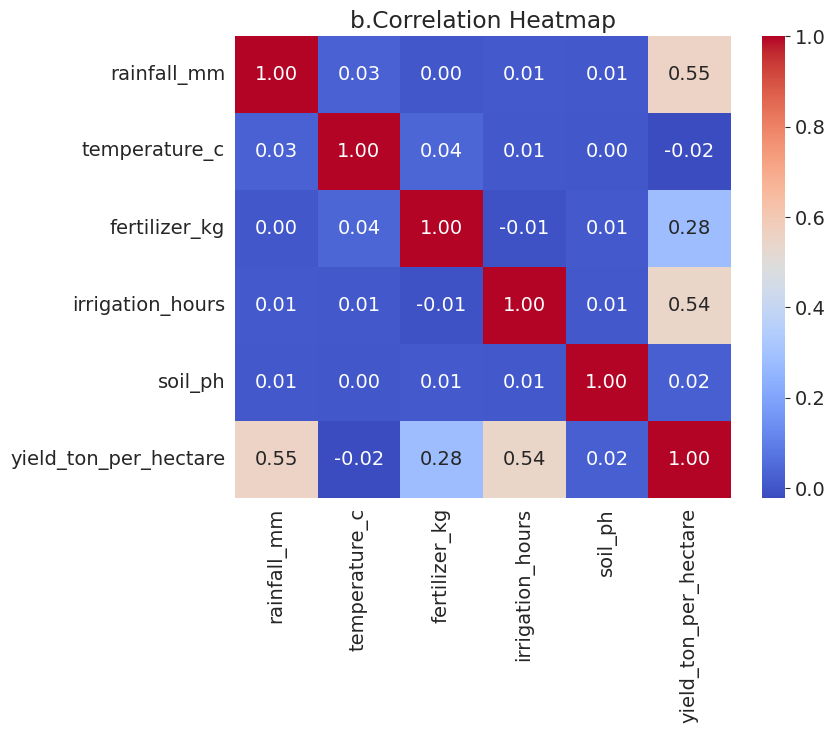

Note: Observations will be mentioned in the report
--------------------------------------------------


Q10. Group-Based Analysis: 
Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop Rice with Highest Average Yield: 5.49ton/hectare

Crop Loamy with Highest Average Yield: 5.37ton/hectare


In [42]:
#--------------------PART B : Exploratory Data Analysis--------------------

!pip install plotly matplotlib seaborn --quiet
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10, 6)
matplotlib.rcParams['figure.facecolor']='#00000000'

# Distribution Analysis
print("Q4. Distribution Analysis: ")
# Rainfall
fig_rain=px.histogram(df,
                 x='rainfall_mm',
                 marginal='box',
                 nbins=30,
                 color_discrete_sequence=['blue'],
                 title='Distribution of Rainfall (mm)',)
fig_rain.update_layout(bargap=0.1)
fig_rain.show()
# Temperature
fig_temp=px.histogram(
    df,
    x='temperature_c',
    marginal='box',
    nbins=20,
    color_discrete_sequence=['green'],
    title='Distribution of Temperature (°C)')
fig_temp.update_layout(bargap=0.1)
fig_temp.show()

# Fertilizer
fig_fert=px.histogram(
    df,
    x='fertilizer_kg',
    marginal='box',
    nbins=40,
    color_discrete_sequence=['red'],
    title='Distribution of Fertilizer Usage (kg)')
fig_fert.update_layout(bargap=0.1)
fig_fert.show()

# Yield
fig_yield=px.histogram(
    df,
    x='yield_ton_per_hectare',
    marginal='box',
    nbins=10,
    title='Distribution of Yield (Ton per Hectare)')
fig_yield.update_layout(bargap=0.1)
fig_yield.show()

print("Note: Observations will be mentioned in the report")
print('-'*50)

# Crop Type Analysis
print("\n\nQ5. Crop Type Analysis: ")
print("a.Number of Records for Each Crop Type:")
print(df['crop_type'].value_counts())

crop_counts = df['crop_type'].value_counts().reset_index()
crop_counts.columns = ['crop_type', 'count']
px.bar(
    crop_counts,
    x='crop_type',
    y='count',
    title='b.Crop Type Distribution'
).show()

print("c.Most frequent crop:", df['crop_type'].mode()[0])
print('-'*50)

# Soil Type Analysis
print("\n\nQ6. Soil Type Analysis: ")
print("a.Number of Records for Each Soil Type:")
print(df['soil_type'].value_counts())

crop_counts = df['soil_type'].value_counts().reset_index()
crop_counts.columns = ['soil_type', 'count']
px.bar(
    crop_counts,
    x='soil_type',
    y='count',
    title='b.Soil Type Distribution'
).show()

print("c.Most frequent soil type:", df['soil_type'].mode()[0])
print('-'*50)

# Yield Distribution
print("\n\nQ7. Yield Distribution: ")
fig_yield=px.histogram(
    df,
    x='yield_ton_per_hectare',
    marginal='box',
    nbins=10,
    title='Distribution of Yield (Ton per Hectare)')
fig_yield.update_layout(bargap=0.1)
fig_yield.show()

print("Note: Observations will be mentioned in the report")
print('-'*50)

# Scatter Plot Analysis
print("\n\nQ8. Scatter Plot Analysis: ")
fig = px.scatter(
    df,
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    title='Rainfall vs Yield',
    trendline='ols'
)
fig.show()

fig = px.scatter(
    df,
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    title='Fertilizer vs Yield',
    trendline='ols'
)
fig.show()
print("Note: Observations will be mentioned in the report")
print('-'*50)

# Correlation Analysis
print("\n\nQ9. Correlation Analysis: ")

numerical_df = df.select_dtypes(include=['number'])# Select only numerical columns

corr_matrix = numerical_df.corr()
print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('b.Correlation Heatmap')
plt.show()
print("Note: Observations will be mentioned in the report")
print('-'*50)

# Group-Based Analysis
print("\n\nQ10. Group-Based Analysis: ")
# Average yield for each crop type
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print("Average Yield by Crop Type:")
print(crop_yield)

# Average yield for each soil type
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Soil Type:")
print(soil_yield)

#Highest average yield
best_crop = crop_yield.idxmax()
best_crop_yield = crop_yield.max()
print(f"\nCrop {best_crop} with Highest Average Yield: {best_crop_yield:.2f}ton/hectare")

best_soil = soil_yield.idxmax()
best_soil_yield = soil_yield.max()
print(f"\nCrop {best_soil} with Highest Average Yield: {best_soil_yield:.2f}ton/hectare")

In [56]:
#--------------------PART C : Data Preparation--------------------
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#  Feature Encoding
print("Q11. Feature Encoding: ")
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"a.Categorical Features: {categorical_features}")

le = LabelEncoder()
df_processed=df.copy()
df_processed['soil_type']=le.fit_transform(df_processed['soil_type'])
df_processed['crop_type']=le.fit_transform(df_processed['crop_type'])
print("\nb.All the categorical features are converted to numerical")

print("\nc. First 5 records: ")
print(df_processed.head())

# Feature Selection
print("\n\nQ12. Feature Selection: ")
X = df_processed.drop('yield_ton_per_hectare', axis=1)
y = df_processed['yield_ton_per_hectare']
print("Note: yield_ton_per_hectare feature is being used as the target variable")

Q11. Feature Encoding: 
a.Categorical Features: ['crop_type', 'soil_type']

b.All the categorical features are converted to numerical

c. First 5 records: 
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type  soil_type  yield_ton_per_hectare  
0          1          1                   5.92  
1          1          2                   6.24  
2          4          2                   4.77  
3          1          1                   4.04  
4          0          0                   5.17  


Q12. Feature Selection: 
Note: yield_ton_per_hectare feature is being used as the target variable

In [55]:
#--------------------PART D : Machine Learning--------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score ,confusion_matrix

# Train-Test Split
print("Q13. Train-Test Split: ")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\na.Split completed. Training set: {X_train.shape[0]} rows. Testing set: {X_test.shape[0]} rows.")

print("\nb. Display the shape of: ")
print(f"X_train: {X_train.shape}\nX_test: {X_test.shape}")
print(f"y_train: {y_train.shape}\ny_test: {y_test.shape}")

# Linear Regression Model
print("\n\nQ14. Linear Regression Model: ")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("a.Linear Regression model trained to predict Yield in tonnes per hectare.")

print("\nb.Display the model coefficients and intercept.")
print("--Model Coefficients:")
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
print(coeff_df)
print("--Intercept:")
print(lr_model.intercept_)

highest_feature = coeff_df.loc[
    coeff_df['Coefficient'].idxmax()
]
print(f"\nc.Feature with Highest Positive Coefficient:\n{highest_feature}")



Q13. Train-Test Split: 

a.Split completed. Training set: 1200 rows. Testing set: 300 rows.

b. Display the shape of: 
X_train: (1200, 7)
X_test: (300, 7)
y_train: (1200,)
y_test: (300,)


Q14. Linear Regression Model: 
a.Linear Regression model trained to predict Yield in tonnes per hectare.

b.Display the model coefficients and intercept.
--Model Coefficients:
            Feature  Coefficient
0       rainfall_mm     0.002083
1     temperature_c    -0.009600
2     fertilizer_kg     0.004713
3  irrigation_hours     0.201737
4           soil_ph     0.003532
5         crop_type     0.090973
6         soil_type    -0.247006
--Intercept:
1.9705093543420662

c.Feature with Highest Positive Coefficient:
Feature        irrigation_hours
Coefficient            0.201737
Name: 3, dtype: object
